<a href="https://colab.research.google.com/github/alearecuest/anyoneai-exercises-sprint_3/blob/main/17_3_3_THEORY_Implementing_attention_step_by_step_in_Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step by step implementation of the Attention Mechanism

Attention mechanisms have become a vital component in modern neural networks, particularly in tasks involving sequence processing, such as machine translation, text summarization, and more. The core idea behind attention is to allow the model to focus on specific parts of the input sequence when generating each output, rather than relying on a single fixed-size context vector, as is the case in traditional sequence-to-sequence models.

In this notebook, we present a step by step example implementation of two popular attention mechanisms: Bahdanau Attention (additive attention) and Luong Attention (multiplicative attention). Both of these mechanisms help improve the model’s ability to attend to relevant parts of the input by computing alignment scores between the decoder’s previous hidden state and the encoder’s hidden states. The attention scores are then used to generate a weighted context vector, which is fed into the decoder to enhance the prediction.

Through this toy example, we’ll visualize how these attention mechanisms differ and gain a better understanding of how they can be applied to improve performance in various sequence processing tasks.

In [ ]:
# Import required libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Layer
import matplotlib.pyplot as plt
from gensim.models import KeyedVectors

In [ ]:
### Connect to drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set path
# %cd /content/drive/MyDrive/AnyoneAI/17. Word2Vec/
%cd /content/drive/MyDrive/AnyoneAI
!ls

/content/drive/MyDrive/AnyoneAI
word2vec-google-news-300.model	word2vec-google-news-300.model.vectors.npy


In [ ]:
# Example sentence
sentence = "Attention mechanisms allow neural networks to focus on specific parts of the input sequence."
words = sentence.lower().split()
words

['attention',
 'mechanisms',
 'allow',
 'neural',
 'networks',
 'to',
 'focus',
 'on',
 'specific',
 'parts',
 'of',
 'the',
 'input',
 'sequence.']

In [ ]:
# Load a Pre-trained word2vec

# If you don't have the model locally, use the following lines to download and save:
# w2v_model = api.load("word2vec-google-news-300")
# Save the model locally
# w2v_model.save("word2vec-google-news-300.model")

# Load the model locally:
w2v_model = KeyedVectors.load("word2vec-google-news-300.model")

In [ ]:
def words_to_vectors(words, word2vec_model):
    """Converts a list of words to vectors using the word2vec model."""
    return np.array([word2vec_model[word] if word in word2vec_model else np.zeros(300) for word in words])

def prepare_data(words, word2vec_model):
    """Prepares the input data and initializes random hidden states."""
    # Convert words to vectors
    encoder_inputs = words_to_vectors(words, word2vec_model)

    # Initialize random hidden states for the encoder and decoder
    encoder_hidden_states = np.random.rand(len(words), 256)
    decoder_hidden_state = np.random.rand(256)

    return encoder_inputs, encoder_hidden_states, decoder_hidden_state

encoder_inputs, encoder_hidden_states, decoder_hidden_state = prepare_data(words, w2v_model)

## Attention Mechanisms in Neural Networks

### 1. Bahdanau Attention (Additive Attention)

Bahdanau attention, introduced by Dzmitry Bahdanau, Kyunghyun Cho, and Yoshua Bengio in their 2014 paper, "Neural Machine Translation by Jointly Learning to Align and Translate," uses a feedforward neural network to compute alignment scores. This mechanism allows the model to learn which parts of the input sequence to focus on at each decoding step.

#### Equations

1. **Alignment Scores**:
   $$
   e_{ij} = v_a^T \tanh(W_a s_{i-1} + U_a h_j)
   $$
   where:
   - $ s_{i-1} $ is the previous decoder hidden state.
   - $ h_j $ is the encoder hidden state.
   - $ W_a $, $U_a$, and $v_a$ are learnable parameters.

2. **Attention Weights**:
   $$
   \alpha_{ij} = \frac{\exp(e_{ij})}{\sum_k \exp(e_{ij})}
   $$

3. **Context Vector**:
   $$
   c_i = \sum_j \alpha_{ij} h_j
   $$

4. **Decoder Output**:
   $$
   s_i = \text{RNN}(s_{i-1}, y_{i-1}, c_i)
   $$
   where:
   - $ y_{i-1} $ is the previous target output.
   - The RNN can be an LSTM or GRU.

In [ ]:
class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W_a = tf.keras.layers.Dense(units)
        self.U_a = tf.keras.layers.Dense(units)
        self.V_a = tf.keras.layers.Dense(1)

    def call(self, encoder_hidden_states, decoder_hidden_state):

        decoder_hidden_state = tf.expand_dims(decoder_hidden_state, axis=-1)

        # Compute the alignment scores
        query_with_time_axis = tf.expand_dims(decoder_hidden_state, 1)
        scores = self.V_a(tf.nn.tanh(self.W_a(query_with_time_axis) + self.U_a(encoder_hidden_states)))

        # Compute attention weights
        attention_weights = tf.nn.softmax(scores, axis=1)

        # Compute the context vector
        context_vector = attention_weights * encoder_hidden_states
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

# Initialize Bahdanau Attention
bahdanau_attention = BahdanauAttention(units=256)

# Compute context vector and attention weights
context_vector_bahdanau, attention_weights_bahdanau = bahdanau_attention(encoder_hidden_states, decoder_hidden_state)


### 2. Luong Attention (Multiplicative Attention)

Luong attention, introduced by Minh-Thang Luong, Hieu Pham, and Christopher D. Manning in their 2015 paper, "Effective Approaches to Attention-based Neural Machine Translation," uses a dot product or a general linear transformation to compute alignment scores. This method is simpler and more computationally efficient than Bahdanau attention.

#### Equations

1. Either a **dot-product score** is used:
   $$
   e_{ij} = s_{i-1}^T h_j
   $$

   or a more **general score**:
   $$
   e_{ij} = s_{i-1}^T W_a h_j
   $$

   where $W_a$ is a learnable parameter matrix. Note that if $W_a$ is the identity matrix (no learnable parameters), we obtain the simpler dot-product score.

3. **Attention Weights**:
   $$
   \alpha_{ij} = \frac{\exp(e_{ij})}{\sum_k \exp(e_{ij})}
   $$

4. **Context Vector**:
   $$
   c_i = \sum_j \alpha_{ij} h_j
   $$

5. **Final Output**:
   $$
   \tilde{s}_i = \tanh(W_c [c_i; s_i])
   $$
   where:
   - $ W_c $ is a learnable parameter matrix.
   - $[c_i; s_i]$ denotes the concatenation of the context vector and the decoder hidden state.

In [ ]:
# Luong Attention Implementation
class LuongAttention(Layer):
    def __init__(self, units):
        super(LuongAttention, self).__init__()
        self.units = units
        self.W_a = tf.keras.layers.Dense(units)  # For general score

    def call(self, encoder_hidden_states, decoder_hidden_state):

        decoder_hidden_state = tf.expand_dims(decoder_hidden_state, axis=-1)

        # Dot-Product Score
        # scores = tf.matmul(encoder_hidden_states, decoder_hidden_state)

        # General Score
        scores = tf.matmul(encoder_hidden_states, self.W_a(decoder_hidden_state))

        # Compute attention weights
        attention_weights = tf.nn.softmax(scores, axis=1)

        # Compute the context vector
        context_vector = attention_weights * encoder_hidden_states
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector, attention_weights

# Initialize Luong Attention
luong_attention = LuongAttention(units=256)

# Compute context vector and attention weights
context_vector_luong, attention_weights_luong = luong_attention(encoder_hidden_states, decoder_hidden_state)

### Plot attention

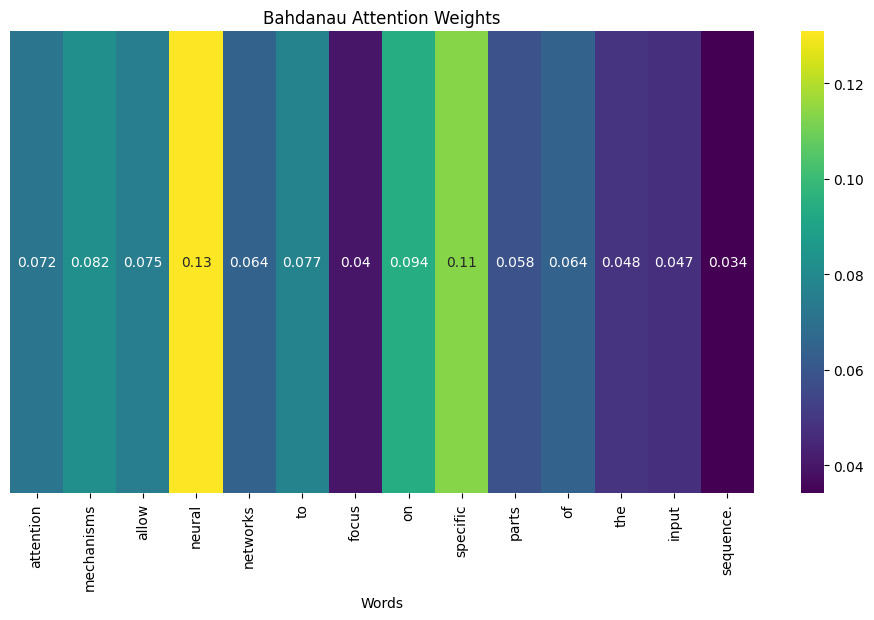

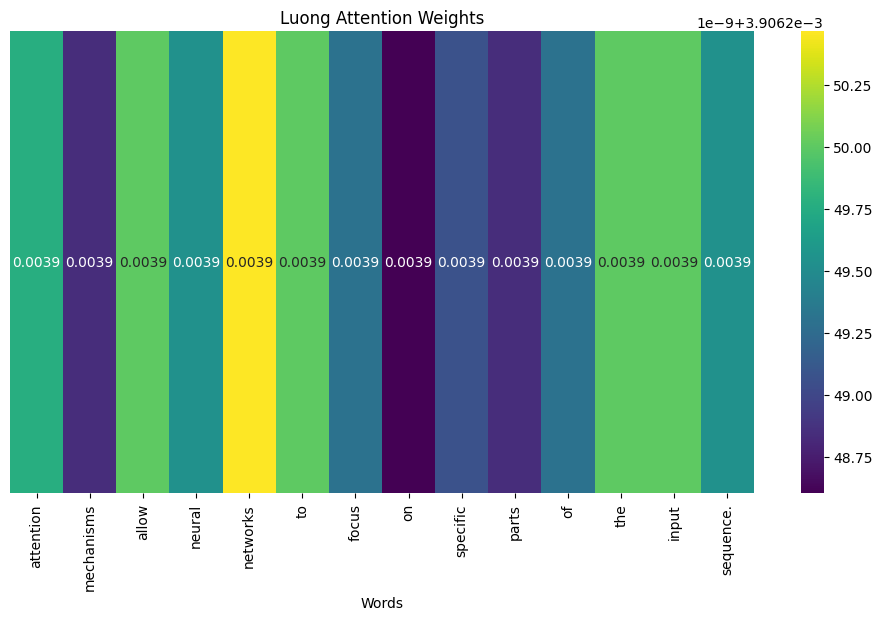

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_attention_weights(attention_weights, words, title='Attention Weights'):
    """
    Plots attention weights for each word.

    Args:
    attention_weights (numpy array): The attention weights matrix.
                                     Shape should be (256, 14, 1) for Bahdanau or (14, 256) for Luong.
    words (list): List of words corresponding to the attention weights.
    title (str): Title of the plot.
    """
    if attention_weights.ndim == 3:
        # Bahdanau: Convert shape (256, 14, 1) to (256, 14)
        attention_weights = tf.squeeze(attention_weights, axis=-1)
        # attention_weights = .squeeze()

    if attention_weights.shape[0] == 14:
        # Luong: Transpose to get shape (14, 256) to (256, 14)
        attention_weights = tf.transpose(attention_weights)

    avg_attention_weights = np.mean(attention_weights, axis=0)

    plt.figure(figsize=(12, 6))
    sns.heatmap(avg_attention_weights[np.newaxis, :], cmap='viridis', cbar=True, annot=True, xticklabels=words)
    plt.yticks([], [])
    plt.title(title)
    plt.xlabel('Words')
    plt.show()

# Plot Bahdanau Attention Weights
plot_attention_weights(attention_weights_bahdanau, words, title='Bahdanau Attention Weights')

# Plot Luong Attention Weights
plot_attention_weights(attention_weights_luong, words, title='Luong Attention Weights')
